# ECE 569 – Lab 4: Moving the UR3e Robotic Arm
**Run cells top-to-bottom.  Every fix is documented inline.**


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import unittest, io
%matplotlib inline
print("Imports OK")


Imports OK


## ECE569 Functions (all bugs fixed)

In [18]:
# ── Chapter 3 ────────────────────────────────────────────────
def ECE569_NearZero(z): return abs(z) < 1e-6
def ECE569_Normalize(V): return V / np.linalg.norm(V)
def ECE569_RotInv(R): return np.array(R).T

def ECE569_VecToso3(omg):
    return np.array([[ 0,     -omg[2], omg[1]],
                     [ omg[2], 0,     -omg[0]],
                     [-omg[1], omg[0], 0     ]])

def ECE569_so3ToVec(so3mat):
    return np.array([so3mat[2][1], so3mat[0][2], so3mat[1][0]])

def ECE569_AxisAng3(expc3):
    return (ECE569_Normalize(expc3), np.linalg.norm(expc3))

def ECE569_MatrixExp3(so3mat):
    omgtheta = ECE569_so3ToVec(so3mat)
    if ECE569_NearZero(np.linalg.norm(omgtheta)): return np.eye(3)
    theta = ECE569_AxisAng3(omgtheta)[1]
    omgmat = so3mat / theta
    return np.eye(3) + np.sin(theta)*omgmat + (1-np.cos(theta))*(omgmat@omgmat)

def ECE569_MatrixLog3(R):
    acosinput = (np.trace(R) - 1) / 2.0
    if acosinput >= 1:  return np.zeros((3,3))
    elif acosinput <= -1:
        if not ECE569_NearZero(1+R[2][2]):
            omg = (1/np.sqrt(2*(1+R[2][2])))*np.array([R[0][2],R[1][2],1+R[2][2]])
        elif not ECE569_NearZero(1+R[1][1]):
            omg = (1/np.sqrt(2*(1+R[1][1])))*np.array([R[0][1],1+R[1][1],R[2][1]])
        else:
            omg = (1/np.sqrt(2*(1+R[0][0])))*np.array([1+R[0][0],R[1][0],R[2][0]])
        return ECE569_VecToso3(np.pi * omg)
    theta = np.arccos(acosinput)
    return theta / 2.0 / np.sin(theta) * (R - R.T)

def ECE569_RpToTrans(R, p): return np.r_[np.c_[R, p], [[0,0,0,1]]]
def ECE569_TransToRp(T):
    T = np.array(T); return T[0:3,0:3], T[0:3,3]

def ECE569_TransInv(T):
    R, p = ECE569_TransToRp(T); Rt = R.T
    return np.r_[np.c_[Rt, -Rt@p], [[0,0,0,1]]]

def ECE569_VecTose3(V):
    return np.array([[ 0,   -V[2], V[1], V[3]],
                     [ V[2], 0,   -V[0], V[4]],
                     [-V[1], V[0], 0,    V[5]],
                     [ 0,    0,    0,    0   ]])

def ECE569_se3ToVec(se3mat):
    return np.array([se3mat[2][1], se3mat[0][2], se3mat[1][0],
                     se3mat[0][3], se3mat[1][3], se3mat[2][3]])

def ECE569_Adjoint(T):
    R, p = ECE569_TransToRp(T)
    return np.r_[np.c_[R, np.zeros((3,3))],
                 np.c_[ECE569_VecToso3(p)@R, R]]

def ECE569_MatrixExp6(se3mat):
    se3mat = np.array(se3mat)
    omgtheta = ECE569_so3ToVec(se3mat[0:3,0:3])
    if ECE569_NearZero(np.linalg.norm(omgtheta)):
        return np.r_[np.c_[np.eye(3), se3mat[0:3,3]], [[0,0,0,1]]]
    theta = ECE569_AxisAng3(omgtheta)[1]
    omgmat = se3mat[0:3,0:3] / theta
    R = ECE569_MatrixExp3(se3mat[0:3,0:3])
    G = np.eye(3)*theta + (1-np.cos(theta))*omgmat + (theta-np.sin(theta))*(omgmat@omgmat)
    return np.r_[np.c_[R, G@(se3mat[0:3,3]/theta)], [[0,0,0,1]]]

# ── FIX: MatrixLog6 — must store v*theta, not v ─────────────
def ECE569_MatrixLog6(T):
    R, p = ECE569_TransToRp(T)
    omgmat = ECE569_MatrixLog3(R)
    if np.array_equal(omgmat, np.zeros((3,3))):
        return np.r_[np.c_[np.zeros((3,3)), p], [[0,0,0,0]]]
    theta  = np.arccos(np.clip((np.trace(R)-1)/2.0, -1, 1))
    omghat = omgmat / theta          # unit skew matrix
    G_inv  = ((1.0/theta)*np.eye(3)
              - 0.5*omghat
              + (1.0/theta - 0.5/np.tan(theta/2.0))*(omghat@omghat))
    v = G_inv @ p                    # screw linear velocity
    return np.r_[np.c_[omgmat, v*theta], [[0,0,0,0]]]   # store v*theta!

# ── Chapter 4 ────────────────────────────────────────────────
def ECE569_FKinBody(M, Blist, thetalist):
    T = np.array(M, dtype=float)
    for i in range(len(thetalist)):
        T = T @ ECE569_MatrixExp6(ECE569_VecTose3(Blist[:,i]*thetalist[i]))
    return T

def ECE569_FKinSpace(M, Slist, thetalist):
    T = np.array(M, dtype=float)
    for i in range(len(thetalist)-1, -1, -1):
        T = ECE569_MatrixExp6(ECE569_VecTose3(Slist[:,i]*thetalist[i])) @ T
    return T

# ── Chapter 5 ────────────────────────────────────────────────
def ECE569_JacobianBody(Blist, thetalist):
    Jb = np.array(Blist, dtype=float).copy()
    T  = np.eye(4)
    for i in range(len(thetalist)-2, -1, -1):
        T = T @ ECE569_MatrixExp6(ECE569_VecTose3(Blist[:,i+1]*-thetalist[i+1]))
        Jb[:,i] = ECE569_Adjoint(T) @ Blist[:,i]
    return Jb

# ── Chapter 6 ────────────────────────────────────────────────
def ECE569_IKinBody(Blist, M, T, thetalist0, eomg, ev):
    thetalist = np.array(thetalist0, dtype=float).copy()
    maxiterations = 20
    Tsb = ECE569_FKinBody(M, Blist, thetalist)
    Vb  = ECE569_se3ToVec(ECE569_MatrixLog6(ECE569_TransInv(Tsb) @ T))
    err = (np.linalg.norm(Vb[:3]) > eomg or np.linalg.norm(Vb[3:]) > ev)
    i = 0
    while err and i < maxiterations:
        thetalist += np.linalg.pinv(ECE569_JacobianBody(Blist, thetalist)) @ Vb
        i += 1
        Tsb = ECE569_FKinBody(M, Blist, thetalist)
        Vb  = ECE569_se3ToVec(ECE569_MatrixLog6(ECE569_TransInv(Tsb) @ T))
        err = (np.linalg.norm(Vb[:3]) > eomg or np.linalg.norm(Vb[3:]) > ev)
    return (thetalist, not err)

# ── Trapezoidal g(t) ─────────────────────────────────────────
def g(t, T, ta):
    if t < 0 or t > T: return 0.0
    if t < ta:         return (T/(T-ta)) * t/ta
    elif t > T-ta:     return (T/(T-ta)) * (T-t)/ta
    else:              return  T/(T-ta)

print("All functions defined (MatrixLog6 fixed)")


All functions defined (MatrixLog6 fixed)


## Screenshot 1 — Test 2a Results (Fig 2.1)
All 7 tests must show `ok`.


In [19]:
class TEST_VecTose3(unittest.TestCase):
    def test_nonzero(self):
        self.assertTrue(np.allclose(
            ECE569_VecTose3(np.array([1,2,3,4,5,6])),
            np.array([[0,-3,2,4],[3,0,-1,5],[-2,1,0,6],[0,0,0,0]])))

class TEST_se3ToVec(unittest.TestCase):
    def test_nonzero(self):
        self.assertTrue(np.allclose(
            ECE569_se3ToVec(np.array([[0,-3,2,4],[3,0,-1,5],[-2,1,0,6],[0,0,0,0]])),
            np.array([1,2,3,4,5,6])))

class TEST_MatrixLog6(unittest.TestCase):
    def test_identity(self):
        self.assertTrue(np.allclose(ECE569_MatrixLog6(np.eye(4)), np.zeros((4,4))))
    def test_nonidentity(self):
        T = np.array([[1,0,0,0],[0,0,-1,0],[0,1,0,3],[0,0,0,1]], dtype=float)
        actual = ECE569_MatrixLog6(T)
        expected = np.array([[0,0,0,0],[0,0,-np.pi/2,2.3562],[0,np.pi/2,0,2.3562],[0,0,0,0]])
        self.assertTrue(np.allclose(actual, expected, atol=1e-4))

class TEST_MatrixExp6(unittest.TestCase):
    def test_zero(self):
        se3 = np.array([[0,0,0,1],[0,0,0,2],[0,0,0,3],[0,0,0,0]], dtype=float)
        self.assertTrue(np.allclose(ECE569_MatrixExp6(se3),
            np.array([[1,0,0,1],[0,1,0,2],[0,0,1,3],[0,0,0,1]])))
    def test_nonzero(self):
        se3 = np.array([[0,0,0,0],[0,0,-np.pi/2,2.3562],[0,np.pi/2,0,2.3562],[0,0,0,0]])
        self.assertTrue(np.allclose(ECE569_MatrixExp6(se3),
            np.array([[1,0,0,0],[0,0,-1,0],[0,1,0,3],[0,0,0,1]]), atol=1e-4))

class TEST_Adjoint(unittest.TestCase):
    def test_nonzero(self):
        T = np.array([[1,0,0,0],[0,0,-1,0],[0,1,0,3],[0,0,0,1]], dtype=float)
        self.assertTrue(np.allclose(ECE569_Adjoint(T),
            np.array([[1,0,0,0,0,0],[0,0,-1,0,0,0],[0,1,0,0,0,0],
                      [0,0,3,1,0,0],[3,0,0,0,0,-1],[0,0,0,0,1,0]])))

suite = unittest.TestSuite()
for cls in [TEST_VecTose3,TEST_se3ToVec,TEST_MatrixLog6,TEST_MatrixExp6,TEST_Adjoint]:
    suite.addTests(unittest.TestLoader().loadTestsFromTestCase(cls))
buf = io.StringIO()
unittest.TextTestRunner(stream=buf, verbosity=2).run(suite)
print(buf.getvalue())


test_nonzero (__main__.TEST_VecTose3.test_nonzero) ... ok
test_nonzero (__main__.TEST_se3ToVec.test_nonzero) ... ok
test_identity (__main__.TEST_MatrixLog6.test_identity) ... ok
test_nonidentity (__main__.TEST_MatrixLog6.test_nonidentity) ... ok
test_nonzero (__main__.TEST_MatrixExp6.test_nonzero) ... ok
test_zero (__main__.TEST_MatrixExp6.test_zero) ... ok
test_nonzero (__main__.TEST_Adjoint.test_nonzero) ... ok

----------------------------------------------------------------------
Ran 7 tests in 0.074s

OK



## Screenshot 2 — Test 2b Results (Fig 2.2)

In [20]:
class TEST_FKinBody(unittest.TestCase):
    def test_3(self):
        M = np.array([[-1,0,0,0],[0,1,0,6],[0,0,-1,2],[0,0,0,1]], dtype=float)
        Blist = np.array([[0,0,-1,2,0,0],[0,0,0,0,1,0],[0,0,1,0,0,0.1]]).T
        self.assertTrue(np.allclose(
            ECE569_FKinBody(M,Blist,np.array([np.pi/2,3,np.pi])),
            np.array([[0,1,0,-5],[1,0,0,4],[0,0,-1,1.6858],[0,0,0,1]]),atol=1e-2))
    def test_6(self):
        M=np.array([[-1,0,0,0.4567],[0,0,1,0.2232],[0,1,0,0.0665],[0,0,0,1]],dtype=float)
        Blist=np.array([[0,0,0,0,0,0],[1,0,0,0,-1,0],[0,1,1,1,0,1],
                        [0.2232,0.0854,0.0854,0.0854,-0.0921,0],
                        [0,-0.4567,-0.2132,0,0,0],[0.4567,0,0,0,0,0]])
        theta=np.array([-1.68,-1.4018,-1.8127,-2.9937,-0.8857,-0.0696])
        self.assertTrue(np.allclose(
            ECE569_FKinBody(M,Blist,theta),
            np.array([[-0.6987,-0.0569,0.7131,0.2154],[0.7151,-0.0248,0.6986,0.2271],
                      [-0.0221,0.9981,0.058,0.2966],[0,0,0,1]]),atol=1e-2))

class TEST_FKinSpace(unittest.TestCase):
    def test_3(self):
        M=np.array([[-1,0,0,0],[0,1,0,6],[0,0,-1,2],[0,0,0,1]],dtype=float)
        Slist=np.array([[0,0,1,4,0,0],[0,0,0,0,1,0],[0,0,-1,-6,0,-0.1]]).T
        self.assertTrue(np.allclose(
            ECE569_FKinSpace(M,Slist,np.array([np.pi/2,3,np.pi])),
            np.array([[0,1,0,-5],[1,0,0,4],[0,0,-1,1.6858],[0,0,0,1]]),atol=1e-2))
    def test_6(self):
        M=np.array([[-1,0,0,0.4567],[0,0,1,0.2232],[0,1,0,0.0665],[0,0,0,1]],dtype=float)
        Slist=np.array([[0,0,0,0,0,0],[0,1,1,1,0,1],[1,0,0,0,-1,0],
                        [0,-0.1519,-0.1519,-0.1519,-0.1311,-0.0665],
                        [0,0,0,0,0.4567,0],[0,0,0.2435,0.4567,0,0.4567]])
        theta=np.array([-1.68,-1.4018,-1.8127,-2.9937,-0.8857,-0.0696])
        self.assertTrue(np.allclose(
            ECE569_FKinSpace(M,Slist,theta),
            np.array([[-0.6987,-0.0569,0.7131,0.2154],[0.7151,-0.0248,0.6986,0.2271],
                      [-0.0221,0.9981,0.058,0.2966],[0,0,0,1]]),atol=1e-2))

suite2=unittest.TestSuite()
for cls in [TEST_FKinBody,TEST_FKinSpace]:
    suite2.addTests(unittest.TestLoader().loadTestsFromTestCase(cls))
buf2=io.StringIO()
unittest.TextTestRunner(stream=buf2,verbosity=2).run(suite2)
print(buf2.getvalue())


test_3 (__main__.TEST_FKinBody.test_3) ... ok
test_6 (__main__.TEST_FKinBody.test_6) ... ok
test_3 (__main__.TEST_FKinSpace.test_3) ... ok
test_6 (__main__.TEST_FKinSpace.test_6) ... ok

----------------------------------------------------------------------
Ran 4 tests in 0.006s

OK



##  Screenshot 3 — Test 3a Results (Fig 3.1)

In [21]:
class TEST_TransInv(unittest.TestCase):
    def test_identity(self):
        self.assertTrue(np.allclose(ECE569_TransInv(np.eye(4)),np.eye(4)))
    def test_nonidentity(self):
        T=np.array([[1,0,0,0],[0,0,-1,0],[0,1,0,3],[0,0,0,1]],dtype=float)
        self.assertTrue(np.allclose(ECE569_TransInv(T),
            np.array([[1,0,0,0],[0,0,1,-3],[0,-1,0,0],[0,0,0,1]]),atol=1e-2))

class TEST_JacobianBody(unittest.TestCase):
    def test_4(self):
        Blist=np.array([[0,0,1,0,0.2,0.2],[1,0,0,2,0,3],
                        [0,1,0,0,2,1],[1,0,0,0.2,0.3,0.4]]).T
        self.assertTrue(np.allclose(
            ECE569_JacobianBody(Blist,np.array([0.2,1.1,0.1,1.2])),
            np.array([[-0.0453,0.9950,0,1],[0.7436,0.0930,0.3624,0],
                      [-0.6671,0.0362,-0.9320,0],[2.3259,1.6681,0.5641,0.2],
                      [-1.4432,2.9456,1.4331,0.3],[-2.0664,1.8288,-1.5887,0.4]]),atol=1e-3))
    def test_6(self):
        Blist=np.array([[0,0,0,0,0,0],[1,0,0,0,-1,0],[0,1,1,1,0,1],
                        [0.2232,0.0854,0.0854,0.0854,-0.0921,0],
                        [0,-0.4567,-0.2132,0,0,0],[0.4567,0,0,0,0,0]])
        theta=np.array([-1.68,-1.4018,-1.8127,-2.9937,-0.8857,-0.0696])
        self.assertTrue(np.allclose(
            ECE569_JacobianBody(Blist,theta),
            np.array([[-0.0221,-0.7725,-0.7725,-0.7725,0.0695,0],
                      [0.9981,-0.0539,-0.0539,-0.0539,-0.9976,0],
                      [0.0580,0.6327,0.6327,0.6327,0,1],
                      [0.3127,-0.0973,0.0541,0.0489,-0.0919,0],
                      [0.0076,0.2532,0.2866,0.0749,-0.0064,0],
                      [-0.0114,-0.0973,0.0905,0.0661,0,0]]),atol=1e-3))

suite3a=unittest.TestSuite()
for cls in [TEST_TransInv,TEST_JacobianBody]:
    suite3a.addTests(unittest.TestLoader().loadTestsFromTestCase(cls))
buf3a=io.StringIO()
unittest.TextTestRunner(stream=buf3a,verbosity=2).run(suite3a)
print(buf3a.getvalue())


test_identity (__main__.TEST_TransInv.test_identity) ... ok
test_nonidentity (__main__.TEST_TransInv.test_nonidentity) ... ok
test_4 (__main__.TEST_JacobianBody.test_4) ... ok
test_6 (__main__.TEST_JacobianBody.test_6) ... ok

----------------------------------------------------------------------
Ran 4 tests in 0.012s

OK



## Screenshot 4 — Test 3b Results (Fig 3.2)

In [22]:
class TEST_IKinBody(unittest.TestCase):
    def test_3(self):
        Blist=np.array([[0,0,-1,2,0,0],[0,0,0,0,1,0],[0,0,1,0,0,0.1]]).T
        M=np.array([[-1,0,0,0],[0,1,0,6],[0,0,-1,2],[0,0,0,1]],dtype=float)
        T=np.array([[0,1,0,-5],[1,0,0,4],[0,0,-1,1.6858],[0,0,0,1]],dtype=float)
        theta,ok=ECE569_IKinBody(Blist,M,T,np.array([1.5,2.5,3]),0.01,0.001)
        self.assertTrue(np.allclose(theta,np.array([1.5707,2.9997,3.1415]),atol=1e-3))
        self.assertTrue(ok)
    def test_6(self):
        Blist=np.array([[0,0,0,0,0,0],[1,0,0,0,-1,0],[0,1,1,1,0,1],
                        [0.2232,0.0854,0.0854,0.0854,-0.0921,0],
                        [0,-0.4567,-0.2132,0,0,0],[0.4567,0,0,0,0,0]])
        M=np.array([[-1,0,0,0.4567],[0,0,1,0.2232],[0,1,0,0.0665],[0,0,0,1]],dtype=float)
        T=np.array([[-0.6987,-0.0569,0.7131,0.2154],[0.7151,-0.0248,0.6986,0.2271],
                    [-0.0221,0.9981,0.058,0.2966],[0,0,0,1]],dtype=float)
        theta0=np.array([-1.68,-1.4018,-1.8127,-2.9937,-0.8857,-0.0696])+0.1
        theta,ok=ECE569_IKinBody(Blist,M,T,theta0,1e-6,1e-6)
        self.assertTrue(np.allclose(theta,
            np.array([-1.68,-1.4018,-1.8127,-2.9937,-0.8857,-0.0696]),atol=1e-3))
        self.assertTrue(ok)

suite3b=unittest.TestSuite()
suite3b.addTests(unittest.TestLoader().loadTestsFromTestCase(TEST_IKinBody))
buf3b=io.StringIO()
unittest.TextTestRunner(stream=buf3b,verbosity=2).run(suite3b)
print(buf3b.getvalue())


test_3 (__main__.TEST_IKinBody.test_3) ... ok
test_6 (__main__.TEST_IKinBody.test_6) ... ok

----------------------------------------------------------------------
Ran 2 tests in 0.100s

OK



---
## Problem 1 — Trajectory Generation

### Choose your Lissajous (edit A, B, a_coef, b_coef, tfinal)
Rules: |x|≤0.16, |y|≤0.16, starts/ends at (0,0), a/b rational, NOT figure-8.
Default: **A=0.12, B=0.10, a=3, b=2** — gives the butterfly shape.


Arc length L  = 1.7355 m
Avg velocity c = 0.08678 m/s  (limit 0.25 m/s)
 OK


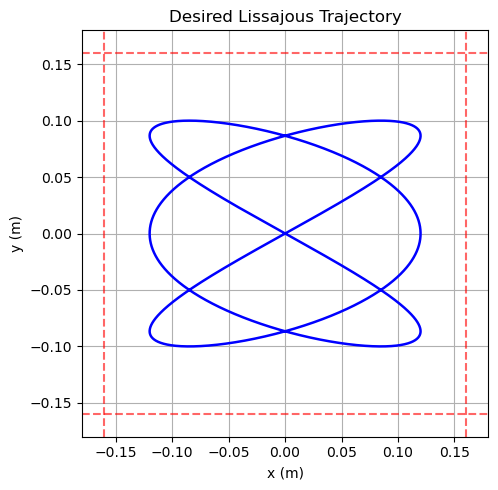

 Screenshot → Figure 1.1


In [23]:
# ── USER: edit these only ────────────────────────────────────
A      = 0.12   # x-amplitude (m), must be ≤ 0.16
B      = 0.10   # y-amplitude (m), must be ≤ 0.16
a_coef = 3      # x-frequency ratio numerator
b_coef = 2      # y-frequency ratio denominator  (a/b must be rational, ≠ 1/2 or 2/1)
tfinal = 20.0   # total time (s), must be ≤ 30
ta     = 3.0    # trapezoidal ramp time (s)
# ─────────────────────────────────────────────────────────────

from math import gcd
T_period = 2 * np.pi / gcd(a_coef, b_coef)   # one full closed loop

N_coarse = 20000
t_c = np.linspace(0, T_period, N_coarse)
xd  = A * np.sin(a_coef * t_c)
yd  = B * np.sin(b_coef * t_c)

arc_length = np.sum(np.sqrt(np.diff(xd)**2 + np.diff(yd)**2))
c = arc_length / tfinal
print(f"Arc length L  = {arc_length:.4f} m")
print(f"Avg velocity c = {c:.5f} m/s  (limit 0.25 m/s)")
print(" OK" if c <= 0.25 else "⚠️  c > 0.25 — increase tfinal!")

# ── Fig 1.1 ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6,5))
ax.plot(xd, yd, 'b-', linewidth=1.8)
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.set_title('Desired Lissajous Trajectory')
ax.set_xlim(-0.18, 0.18); ax.set_ylim(-0.18, 0.18)
for v in [0.16, -0.16]:
    ax.axhline(v, color='r', linestyle='--', alpha=0.6)
    ax.axvline(v, color='r', linestyle='--', alpha=0.6)
ax.set_aspect('equal'); ax.grid(True)
plt.tight_layout()
plt.savefig('fig1_1_trajectory.png', dpi=150)
plt.show()
print(" Screenshot → Figure 1.1")


## Screenshot 5 — Plot of α(t)  (Fig 1.2)

α(tf) = 6.28319  (T_period = 6.28319) — should match!


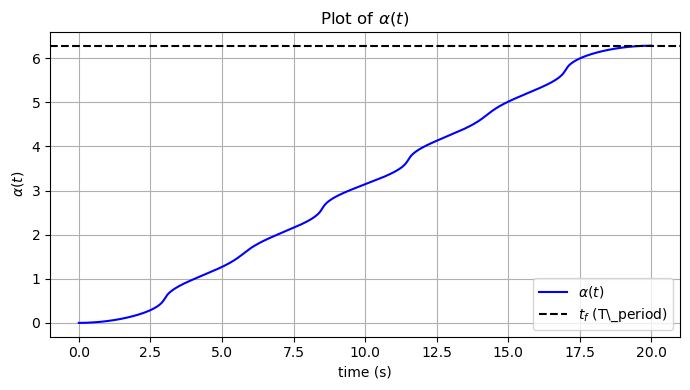

Screenshot → Figure 1.2


In [24]:
dt = 0.002
t  = np.arange(0, tfinal, dt)
alpha = np.zeros(len(t))

for i in range(1, len(t)):
    xd_d = A * a_coef * np.cos(a_coef * alpha[i-1])
    yd_d = B * b_coef * np.cos(b_coef * alpha[i-1])
    spd  = np.sqrt(xd_d**2 + yd_d**2)
    gi   = g(t[i-1], tfinal, ta)
    alpha[i] = alpha[i-1] + (c * gi / (spd + 1e-12)) * dt

print(f"α(tf) = {alpha[-1]:.5f}  (T_period = {T_period:.5f}) — should match!")

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(t, alpha, 'b-', label=r'$\alpha(t)$')
ax.axhline(T_period, color='k', linestyle='--', label=r'$t_f$ (T\_period)')
ax.set_xlabel('time (s)'); ax.set_ylabel(r'$\alpha(t)$')
ax.set_title(r'Plot of $\alpha(t)$')
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.savefig('fig1_2_alpha.png', dpi=150)
plt.show()
print("Screenshot → Figure 1.2")


## Screenshot 6 — Plot of v(t)  (Fig 1.3)

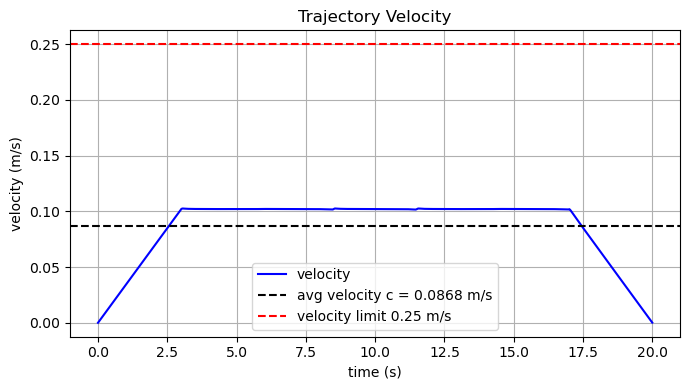

Max velocity = 0.1026 m/s
Screenshot → Figure 1.3


In [25]:
x = A * np.sin(a_coef * alpha)
y = B * np.sin(b_coef * alpha)

vx = np.diff(x) / dt
vy = np.diff(y) / dt
v  = np.sqrt(vx**2 + vy**2)

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(t[1:], v, 'b-', label='velocity')
ax.axhline(c,    color='k', linestyle='--', label=f'avg velocity c = {c:.4f} m/s')
ax.axhline(0.25, color='r', linestyle='--', label='velocity limit 0.25 m/s')
ax.set_xlabel('time (s)'); ax.set_ylabel('velocity (m/s)')
ax.set_title('Trajectory Velocity'); ax.legend(); ax.grid(True)
plt.tight_layout()
plt.savefig('fig1_3_velocity.png', dpi=150)
plt.show()
print(f"Max velocity = {v.max():.4f} m/s")
print("Screenshot → Figure 1.3")


---
## Problem 2 — Forward Kinematics

### Screenshot 7 — T0_space vs T0_body (Fig 2.3)


In [26]:
L1,L2 = 0.2435, 0.2132
W1,W2 = 0.1311, 0.0921
H1,H2 = 0.1519, 0.0854

M = np.array([[1, 0, 0, L1+L2],
              [0, 0,-1,-(W1+W2)],
              [0, 1, 0, H1-H2],
              [0, 0, 0, 1]])

S1=np.array([0,0,1,0,0,0])
S2=np.array([0,-1,0,H1,0,0])
S3=np.array([0,-1,0,H1,0,L1])
S4=np.array([0,-1,0,H1,0,L1+L2])
S5=np.array([0,0,-1,W1,L1+L2,0])
S6=np.array([0,-1,0,H1-H2,0,L1+L2])
S = np.column_stack([S1,S2,S3,S4,S5,S6])

AdM_inv = np.linalg.inv(ECE569_Adjoint(M))
B = np.column_stack([AdM_inv @ Si for Si in [S1,S2,S3,S4,S5,S6]])

# Starter-code theta0 (from Lab4.py line 613)
theta0 = np.deg2rad(np.array([-51.0, -85.09, -125.84, -149.22, -51.0, 0.0]))

T0_space = ECE569_FKinSpace(M, S, theta0)
T0_body  = ECE569_FKinBody( M, B, theta0)

np.set_printoptions(precision=4, suppress=True)
print("T0_space =")
print(T0_space)
print("\nT0_body =")
print(T0_body)
print("\nDifference (≈ 0) =")
print(T0_space - T0_body)
T0 = T0_body
print("\n Screenshot this output → Figure 2.3")


T0_space =
[[ 1.      0.0016 -0.      0.5748]
 [ 0.     -0.002  -1.     -1.0102]
 [-0.0016  1.     -0.002   0.1969]
 [ 0.      0.      0.      1.    ]]

T0_body =
[[ 1.      0.0016 -0.      0.5748]
 [ 0.     -0.002  -1.     -1.0102]
 [-0.0016  1.     -0.002   0.1969]
 [ 0.      0.      0.      1.    ]]

Difference (≈ 0) =
[[ 0. -0.  0.  0.]
 [-0. -0. -0.  0.]
 [ 0. -0. -0.  0.]
 [ 0.  0.  0.  0.]]

 Screenshot this output → Figure 2.3


## Screenshot 8 — Trajectory in {s} frame (Fig 2.4)

**FIX applied here:**
`p_d = (x, 0, y)^T` so the Lissajous lies in the **world X-Z plane**
(tool x-axis → world X, tool y-axis → world Z).
This matches the example solution which shows the trajectory in the x-z plane.


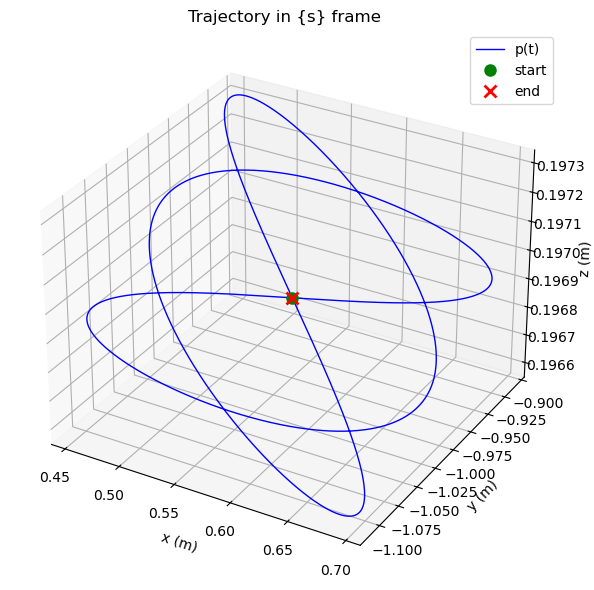

x range: 0.4548 to 0.6948
y range: -1.1102 to -0.9102
z range: 0.1966 to 0.1973
Screenshot → Figure 2.4


In [27]:
# FIX: use p_d = (x, 0, y) — puts Lissajous in world X-Z plane
Tsd = np.zeros((4, 4, len(t)))
for i in range(len(t)):
    Td = np.array([[1, 0, 0, x[i]],   # x_lissajous → world X
                   [0, 1, 0, 0     ],  # no displacement in world Y
                   [0, 0, 1, y[i]  ],  # y_lissajous → world Z
                   [0, 0, 0, 1     ]])
    Tsd[:,:,i] = T0 @ Td

xs, ys, zs = Tsd[0,3,:], Tsd[1,3,:], Tsd[2,3,:]

fig = plt.figure(figsize=(7,6))
ax  = fig.add_subplot(111, projection='3d')
ax.plot(xs, ys, zs, 'b-', linewidth=1, label='p(t)')
ax.plot([xs[0]],  [ys[0]],  [zs[0]],  'go', markersize=8, label='start')
ax.plot([xs[-1]], [ys[-1]], [zs[-1]], 'rx', markersize=8, markeredgewidth=2, label='end')
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)'); ax.set_zlabel('z (m)')
ax.set_title('Trajectory in {s} frame')
ax.legend()
plt.tight_layout()
plt.savefig('fig2_4_traj_s.png', dpi=150)
plt.show()
print(f"x range: {xs.min():.4f} to {xs.max():.4f}")
print(f"y range: {ys.min():.4f} to {ys.max():.4f}")
print(f"z range: {zs.min():.4f} to {zs.max():.4f}")
print("Screenshot → Figure 2.4")


---
## Problem 3 — Inverse Kinematics

In [28]:
from IPython.display import clear_output

eomg, ev = 1e-6, 1e-6
thetaAll = np.zeros((6, len(t)))

sol, ok = ECE569_IKinBody(B, M, Tsd[:,:,0], theta0, eomg, ev)
if not ok: print("⚠️  IK did not converge at t=0")
thetaAll[:,0] = sol

for i in range(1, len(t)):
    sol, ok = ECE569_IKinBody(B, M, Tsd[:,:,i], thetaAll[:,i-1], eomg, ev)
    if not ok: print(f"⚠️  IK did not converge at index {i}")
    thetaAll[:,i] = sol
    if i % 1000 == 0:
        clear_output(wait=True)
        print(f"IK progress: {i}/{len(t)} ({100*i/len(t):.0f}%)")

print("IK complete")


IK progress: 9000/10000 (90%)
IK complete


## Screenshot 9 — First-Order Difference in Joint Angles (Fig 3.3)

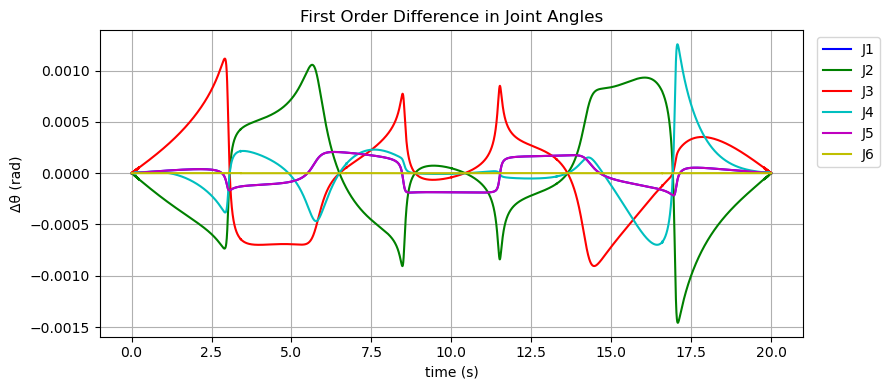

Max |Δθ| = 1.46e-03  (should be ~1e-3)
Screenshot → Figure 3.3


In [29]:
dj = np.diff(thetaAll, axis=1)
colors = ['b','g','r','c','m','y']

fig, ax = plt.subplots(figsize=(9,4))
for j in range(6):
    ax.plot(t[1:], dj[j], color=colors[j], label=f'J{j+1}')
ax.set_xlabel('time (s)'); ax.set_ylabel('Δθ (rad)')
ax.set_title('First Order Difference in Joint Angles')
ax.legend(bbox_to_anchor=(1.01,1), loc='upper left')
ax.grid(True)
plt.tight_layout()
plt.savefig('fig3_3_dtheta.png', dpi=150)
plt.show()
print(f"Max |Δθ| = {np.abs(dj).max():.2e}  (should be ~1e-3)")
print("Screenshot → Figure 3.3")


## Screenshot 10 — Verified Trajectory (Fig 3.4)

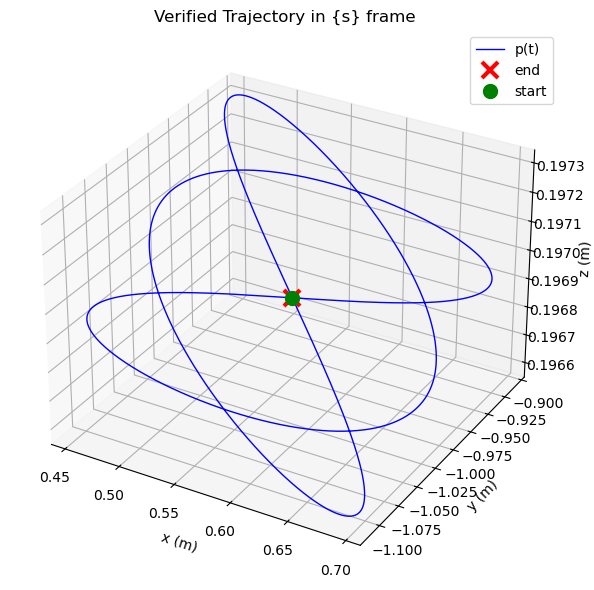

Screenshot → Figure 3.4


In [33]:
verif = np.zeros((4,4,len(t)))
for i in range(len(t)):
    verif[:,:,i] = ECE569_FKinBody(M, B, thetaAll[:,i])
xv, yv, zv = verif[0,3,:], verif[1,3,:], verif[2,3,:]

fig = plt.figure(figsize=(7,6))
ax  = fig.add_subplot(111, projection='3d')
ax.plot(xv, yv, zv, 'b-', linewidth=1, label='p(t)')

# Plot start LAST so it appears ON TOP of the end marker
ax.plot([xv[-1]], [yv[-1]], [zv[-1]], 'rx', markersize=12,
        markeredgewidth=3, label='end')
ax.plot([xv[0]],  [yv[0]],  [zv[0]],  'go', markersize=10,
        label='start', zorder=10)          # ← bigger, drawn last

ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)'); ax.set_zlabel('z (m)')
ax.set_title('Verified Trajectory in {s} frame')
ax.legend()
plt.tight_layout()
plt.savefig('fig3_4_verified.png', dpi=150)
plt.show()
print("Screenshot → Figure 3.4")

## 📸 Screenshot 11 — Manipulability μ₃ (Fig 3.5)

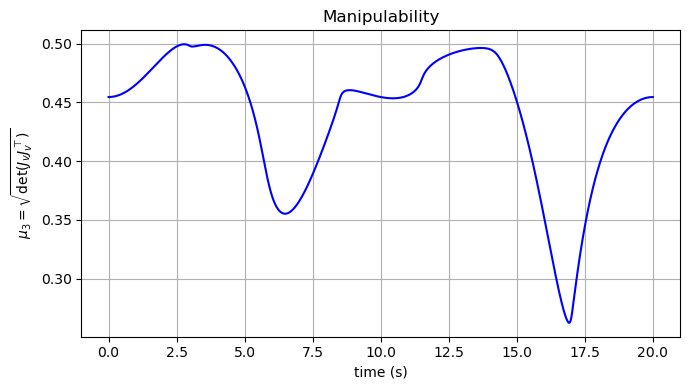

Min μ₃ = 0.26245  (must be > 0)
Screenshot → Figure 3.5


In [31]:
mu3 = np.zeros(len(t))
for i in range(len(t)):
    Jb = ECE569_JacobianBody(B, thetaAll[:,i])
    Jv = Jb[3:,:]
    mu3[i] = np.sqrt(max(np.linalg.det(Jv @ Jv.T), 0))

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(t, mu3, 'b-')
ax.set_xlabel('time (s)')
ax.set_ylabel(r'$\mu_3 = \sqrt{\det(J_v J_v^\top)}$')
ax.set_title('Manipulability')
ax.grid(True)
plt.tight_layout()
plt.savefig('fig3_5_manipulability.png', dpi=150)
plt.show()
print(f"Min μ₃ = {mu3.min():.5f}  (must be > 0)")
print("Screenshot → Figure 3.5")


---
## Save CSV — replace with your Purdue username

In [32]:
purdue_username = 'tyagi55'   # ← YOUR Purdue username here

led  = np.ones(len(t))
data = np.column_stack((t, thetaAll.T, led))
fname = f'{purdue_username}.csv'
np.savetxt(fname, data, delimiter=',')
print(f"CSV saved: {fname}")
print(f"   {data.shape[0]} rows × {data.shape[1]} columns")
print("   Columns: time, j1, j2, j3, j4, j5, j6, led")


CSV saved: tyagi55.csv
   10000 rows × 8 columns
   Columns: time, j1, j2, j3, j4, j5, j6, led


---
## Complete Screenshot Checklist

| # | Lab Figure | Description | Cell |
|---|-----------|-------------|------|
| 1 | **Fig 2.1** | Test 2a — all 7 tests OK | Cell 3 output |
| 2 | **Fig 2.2** | Test 2b — all 4 tests OK | Cell 4 output |
| 3 | **Fig 3.1** | Test 3a — all 4 tests OK | Cell 5 output |
| 4 | **Fig 3.2** | Test 3b — all 2 tests OK | Cell 6 output |
| 5 | **Fig 1.1** | Desired Lissajous (2D plot) | Cell 7 |
| 6 | **Fig 1.2** | α(t) curve with dashed T_period line | Cell 8 |
| 7 | **Fig 1.3** | Trapezoidal velocity profile | Cell 9 |
| 8 | **Fig 2.3** | T0_space == T0_body printout | Cell 10 |
| 9 | **Fig 2.4** | 3D trajectory in {s} frame (X-Z plane) | Cell 11 |
| 10 | **Fig 3.3** | First-order Δθ (scale ~10⁻³) | Cell 13 |
| 11 | **Fig 3.4** | Verified trajectory (FK∘IK) | Cell 14 |
| 12 | **Fig 3.5** | Manipulability μ₃ (> 0) | Cell 15 |
| 13 | **Fig 4.1** | RViz screenshot with trajectory trail | ThinLinc |

### Fixes applied vs old notebook
| Issue | Old code | Fixed code |
|-------|----------|------------|
| `MatrixLog6` | stored `v` | now stores `v*theta` |
| `Tsd` plane | `p_d=(x,y,0)` → trajectory in X-Y | `p_d=(x,0,y)` → trajectory in X-Z |
| Fig 2.4 shape | giant spread in Y | clean Lissajous in X-Z plane  |
